In [ ]:
import torch
from core.utils import show_masks, gray_to_sam_input
from core.utils import load_image
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from segment_anything import SamPredictor
from core.utils import get_prompt_box
from core.utils import show_prompt_masks


In [ ]:
model_type = "vit_b"
checkpoint = "weights/sam_vit_b_01ec64.pth"

# model setup
device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry[model_type](checkpoint=checkpoint)
sam.to(device)
sam.eval()
predictor = SamPredictor(sam)

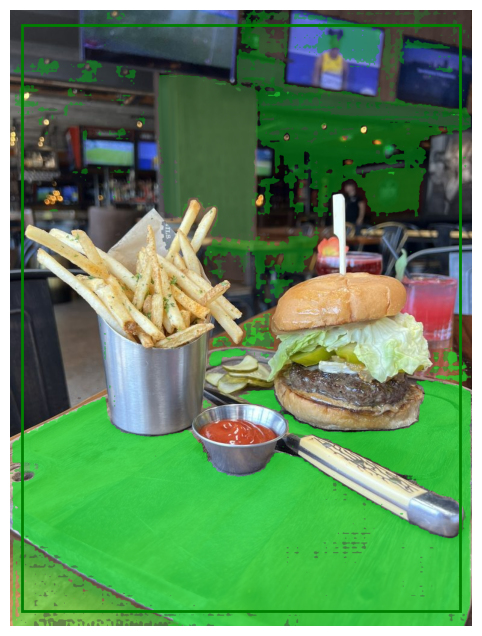

In [8]:

image_path = "photos/wood_dish_1.png"
# image_path = "photos/ok_light_1.png"
# image_path = "photos/good_light_1.png"
image = load_image(image_path)
input_box = get_prompt_box(image, 0.95)
predictor.set_image(image)
masks, scores, logits = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=True,
)

show_prompt_masks(masks, image, alpha=0.5, input_box=input_box)